# Predict Future Sales - Overview / DQC / ETL

First three steps we initialize here:

1. Overview - load everything and see what we got.
2. DQC - go through the data and write down every issue we find.
3. ETL - read that list and actually clean the data based on it. Output is a couple of files ready for further analysis


In [1]:
import time
start = time.time()

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

start = time.time()

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.1f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

INPUT = Path('input')
CACHE = Path('cache')
CACHE.mkdir(exist_ok=True)

# 1. Overview

Just load everything and look at what's inside

In [2]:
# load all the csv files. compact dtypes helps save memory 
sales = pd.read_csv(
    INPUT / 'sales_train.csv',
    dtype={'date_block_num': 'int8', 'shop_id': 'int8', 'item_id': 'int32',
           'item_price': 'float32', 'item_cnt_day': 'float32'},
    parse_dates=['date'], date_format='%d.%m.%Y',
)
items = pd.read_csv(INPUT / 'items.csv', dtype={'item_id': 'int32', 'item_category_id': 'int16'})
categories = pd.read_csv(INPUT / 'item_categories.csv', dtype={'item_category_id': 'int16'})
shops = pd.read_csv(INPUT / 'shops.csv', dtype={'shop_id': 'int8'})
test = pd.read_csv(INPUT / 'test.csv', dtype={'ID': 'int32', 'shop_id': 'int8', 'item_id': 'int32'})
submission = pd.read_csv(INPUT / 'sample_submission.csv')

datasets = {
    'sales_train': sales,
    'items': items,
    'item_categories': categories,
    'shops': shops,
    'test': test,
    'sample_submission': submission,
}
print('loaded', len(datasets), 'tables')

loaded 6 tables


In [3]:
# for each table print shape, dtypes and a couple of rows
for name, df in datasets.items():
    print(f'\n  {name}  shape={df.shape}, {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
    print('dtypes:')
    print(df.dtypes.to_string())
    print('head:')
    print(df.head().to_string())


  sales_train  shape=(2935849, 6), 64.6 MB
dtypes:
date              datetime64[us]
date_block_num              int8
shop_id                     int8
item_id                    int32
item_price               float32
item_cnt_day             float32
head:
        date  date_block_num  shop_id  item_id  item_price  item_cnt_day
0 2013-01-02               0       59    22154       999.0           1.0
1 2013-01-03               0       25     2552       899.0           1.0
2 2013-01-05               0       25     2552       899.0          -1.0
3 2013-01-06               0       25     2554      1709.1           1.0
4 2013-01-15               0       25     2555      1099.0           1.0

  items  shape=(22170, 3), 1.7 MB
dtypes:
item_name             str
item_id             int32
item_category_id    int16
head:
                                                              item_name  item_id  item_category_id
0                             ! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.)         D        0

In [4]:
print(categories['item_category_name'].to_string())

0                      PC - Гарнитуры/Наушники
1                             Аксессуары - PS2
2                             Аксессуары - PS3
3                             Аксессуары - PS4
4                             Аксессуары - PSP
5                          Аксессуары - PSVita
6                        Аксессуары - XBOX 360
7                        Аксессуары - XBOX ONE
8                               Билеты (Цифра)
9                              Доставка товара
10                       Игровые консоли - PS2
11                       Игровые консоли - PS3
12                       Игровые консоли - PS4
13                       Игровые консоли - PSP
14                    Игровые консоли - PSVita
15                  Игровые консоли - XBOX 360
16                  Игровые консоли - XBOX ONE
17                    Игровые консоли - Прочие
18                                  Игры - PS2
19                                  Игры - PS3
20                                  Игры - PS4
21           

In [5]:
# numeric summary of the main table + a few basic facts
desc = sales.select_dtypes(include='number').describe()

# format: count as integer with thousands separator, rest as floats with 2 decimal places
fmt = desc.copy().astype(object)
for col in desc.columns:
    fmt.loc['count', col] = f"{desc.loc['count', col]:,.0f}"
    for row in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
        fmt.loc[row, col] = f"{desc.loc[row, col]:,.2f}"

print('sales_train - numeric summary\n')
print(fmt.to_string())


print(f'\ndate range: {sales["date"].min().date()} => {sales["date"].max().date()}')
print(f'date median: {pd.Timestamp(sales["date"].median()).date()}')
print(f'months: {sales["date_block_num"].nunique()}')
print(f'shops: {sales["shop_id"].nunique():,} of {len(shops):,}')
print(f'items: {sales["item_id"].nunique():,} of {len(items):,}')
print(f'test: {len(test):,} pairs ({test["shop_id"].nunique()} shops x {test["item_id"].nunique():,} items)')

sales_train - numeric summary

      date_block_num    shop_id    item_id  item_price item_cnt_day
count      2,935,849  2,935,849  2,935,849   2,935,849    2,935,849
mean           14.57      33.00  10,197.23      890.85         1.24
std             9.42      16.23   6,324.30    1,729.80         2.62
min             0.00       0.00       0.00       -1.00       -22.00
25%             7.00      22.00   4,476.00      249.00         1.00
50%            14.00      31.00   9,343.00      399.00         1.00
75%            23.00      47.00  15,684.00      999.00         1.00
max            33.00      59.00  22,169.00  307,980.00     2,169.00

date range: 2013-01-01 => 2015-10-31
date median: 2014-03-04
months: 34
shops: 60 of 60
items: 21,807 of 22,170
test: 214,200 pairs (42 shops x 5,100 items)


## 2. DQC (Data Quality Check)

Go through the data and collect all issues into a list. The ETL section below uses this list.

Stuff we look for:
- missing values, duplicate rows
- outliers in price and quantity
- broken references (id in one table missing from another)
- duplicated shops, non-physical shops mixed in
- items with very short history, cold-start items in test

In [6]:
# a small helper to collect issues. each check appends a row here
issues = []

def log_issue(dataset, issue, count, action):
    issues.append({
        'dataset': dataset,
        'issue': issue,
        'count': int(count),
        'action': action,
    })

In [7]:
# check 1 - missing values and full duplicate rows
print('missing values:')
for name, df in datasets.items():
    na = int(df.isna().sum().sum())
    print(' ', name, 'NaN =', na)
    if na > 0:
        log_issue(name, 'missing values', na, 'dropna in ETL')

print('\nduplicates:')
for name, df in datasets.items():
    d = int(df.duplicated().sum())
    print(' ', name, 'duplicates =', d)
    if d > 0:
        log_issue(name, 'duplicate rows', d, 'drop_duplicates in ETL')

missing values:
  sales_train NaN = 0
  items NaN = 0
  item_categories NaN = 0
  shops NaN = 0
  test NaN = 0
  sample_submission NaN = 0

duplicates:
  sales_train duplicates = 6
  items duplicates = 0
  item_categories duplicates = 0
  shops duplicates = 0
  test duplicates = 0
  sample_submission duplicates = 0


item_price <= 0 : 1
item_price > 100k : 1


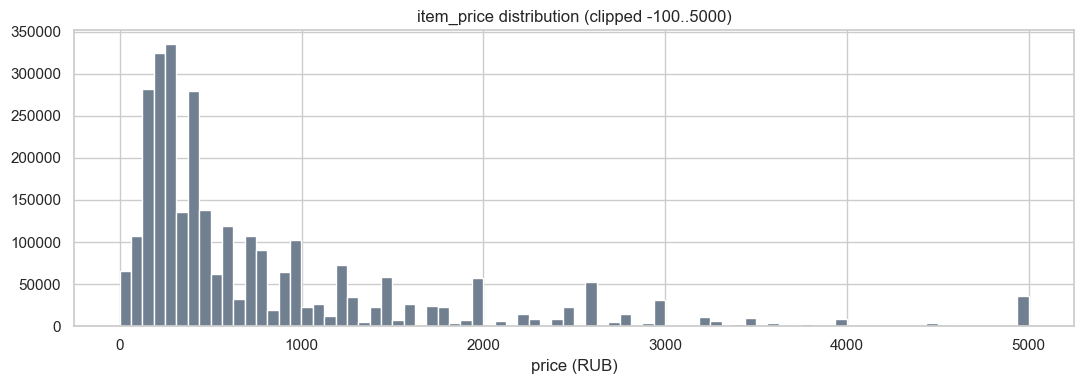

In [8]:
# check 2 - price outliers. look at extremes of the distribution
neg_price = int((sales['item_price'] <= 0).sum())
extreme_price = int((sales['item_price'] > 100_000).sum())

print('item_price <= 0 :', neg_price)
print('item_price > 100k :', extreme_price)

plt.figure(figsize=(11, 4))
plt.hist(sales['item_price'].clip(-100, 5000).to_numpy(), bins=80, color='slategray')
plt.title('item_price distribution (clipped -100..5000)')
plt.xlabel('price (RUB)')
plt.tight_layout()
plt.show()

if neg_price:
    log_issue('sales_train', 'item_price <= 0', neg_price, 'drop in ETL')
if extreme_price:
    log_issue('sales_train', 'item_price > 100k', extreme_price, 'drop in ETL')

item_cnt_day < 0 : 7356
item_cnt_day > 1000 : 1


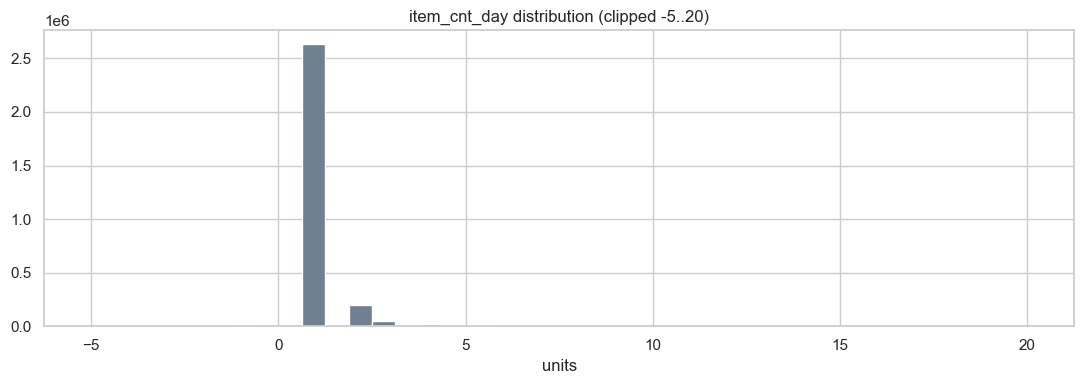

In [9]:
# check 3 - quantity outliers. negative = returns, big numbers mean bulk or errors
returns = int((sales['item_cnt_day'] < 0).sum())
bulk = int((sales['item_cnt_day'] > 1000).sum())

print('item_cnt_day < 0 :', returns)
print('item_cnt_day > 1000 :', bulk)

plt.figure(figsize=(11, 4))
plt.hist(sales['item_cnt_day'].clip(-5, 20).to_numpy(), bins=40, color='slategray')
plt.title('item_cnt_day distribution (clipped -5..20)')
plt.xlabel('units')
plt.tight_layout()
plt.show()

if returns:
    log_issue('sales_train', 'item_cnt_day < 0 (returns)', returns, 'drop in ETL')
if bulk:
    log_issue('sales_train', 'item_cnt_day > 1000', bulk, 'drop in ETL')

In [10]:
# check 4 - integrity between tables
checks = [
    #checking that for each sales table column there exist the same column in reference table
    ('sales.item_id not in items', int(sales.loc[~sales['item_id'].isin(items['item_id']), 'item_id'].nunique())),
    ('test.item_id not in items', int(test.loc[~test['item_id'].isin(items['item_id']), 'item_id'].nunique())),
    ('sales.shop_id not in shops', int(sales.loc[~sales['shop_id'].isin(shops['shop_id']), 'shop_id'].nunique())),
    ('items.item_category_id not in item_categories', int(items.loc[~items['item_category_id'].isin(categories['item_category_id']), 'item_category_id'].nunique())),
]
for label, cnt in checks:
    print(' ', label, ':', cnt)
    if cnt > 0:
        log_issue('cross-table', label, cnt, 'reject unmatched rows in ETL')

  sales.item_id not in items : 0
  test.item_id not in items : 0
  sales.shop_id not in shops : 0
  items.item_category_id not in item_categories : 0


In [11]:
# check 5 - shop issues
# (a) some shops are the same physical store with two different ids
# (b) some 'shops' aren't real stores (online shop, mobile trade) 
shop_dup_map = {0: 57, 1: 58, 10: 11, 39: 40}
non_physical = {12: 'online store', 55: 'digital warehouse', 9: 'mobile trade'}

print('duplicated shops (same point, two ids):')
print(shops[shops['shop_id'].isin(list(shop_dup_map) + list(shop_dup_map.values()))].to_string())

print('\nnon-physical shops:')
print(shops[shops['shop_id'].isin(non_physical)].to_string())

log_issue('shops', 'duplicated shops (same point)', len(shop_dup_map),
          f'merge ids in ETL via map {shop_dup_map}')
log_issue('shops', 'non-physical shops in city column', len(non_physical),
          'tag channel=online/offline/mobile in ETL')

duplicated shops (same point, two ids):
                                          shop_name  shop_id
0                     !Якутск Орджоникидзе, 56 фран        0
1                     !Якутск ТЦ "Центральный" фран        1
10                       Жуковский ул. Чкалова 39м?       10
11                       Жуковский ул. Чкалова 39м²       11
39            РостовНаДону ТРК "Мегацентр Горизонт"       39
40  РостовНаДону ТРК "Мегацентр Горизонт" Островной       40
57                          Якутск Орджоникидзе, 56       57
58                          Якутск ТЦ "Центральный"       58

non-physical shops:
                   shop_name  shop_id
9          Выездная Торговля        9
12       Интернет-магазин ЧС       12
55  Цифровой склад 1С-Онлайн       55


items with <= 3 months of history: 5585 of 21807
cold-start items in test (not seen in train): 363 of 5100


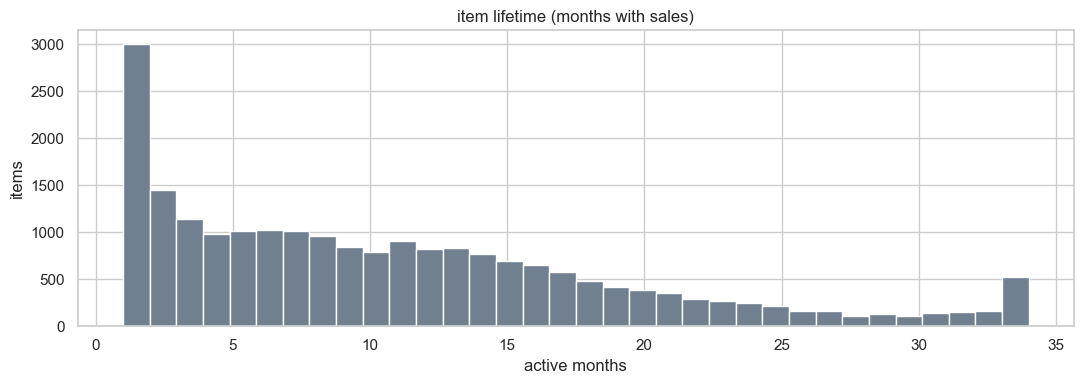

In [12]:
# check 6 - poor dynamics + cold start
# how many items have very short history, and how many test items never appeared in train
item_months = sales.groupby('item_id')['date_block_num'].nunique()
short_3 = int((item_months <= 3).sum())
cold_start = set(test['item_id']) - set(sales['item_id'])

print('items with <= 3 months of history:', short_3, 'of', len(item_months))
print('cold-start items in test (not seen in train):', len(cold_start), 'of', test['item_id'].nunique())

plt.figure(figsize=(11, 4))
plt.hist(item_months.values, bins=34, color='slategray') # type: ignore
plt.title('item lifetime (months with sales)')
plt.xlabel('active months')
plt.ylabel('items')
plt.tight_layout()
plt.show()

log_issue('sales_train', 'items with <= 3 months of history', short_3,
          'flag as short_life in ETL, lag features unreliable')
log_issue('test', 'cold-start items (no history in train)', len(cold_start),
          'fallback to category mean in ETL')

In [13]:
# save the list of issues to a file. ETL section below will read it.
issues_df = pd.DataFrame(issues).sort_values('count', ascending=False).reset_index(drop=True)
issues_df.to_csv(CACHE / 'dqc_issues.csv', index=False)
print('total issues found:', len(issues_df))
issues_df

total issues found: 9


,dataset,issue,count,action
0,sales_train,item_cnt_day < 0 (returns),7356,drop in ETL
1,sales_train,items with <= 3 months of history,5585,"flag as short_life in ETL, lag features unreli..."
2,test,cold-start items (no history in train),363,fallback to category mean in ETL
3,sales_train,duplicate rows,6,drop_duplicates in ETL
4,shops,duplicated shops (same point),4,"merge ids in ETL via map {0: 57, 1: 58, 10: 11..."
5,shops,non-physical shops in city column,3,tag channel=online/offline/mobile in ETL
6,sales_train,item_price <= 0,1,drop in ETL
7,sales_train,item_price > 100k,1,drop in ETL
8,sales_train,item_cnt_day > 1000,1,drop in ETL


# 3. ETL

Now we use the list of issues from DQC and actually clean the data. Output: a cleaned row-level table and a monthly aggregate ready for analysis.

In [14]:
# step 1 - drop rows flagged in DQC: missing, duplicates, price outliers, quantity (qty) outliers, returns
before = len(sales)
mask = (
    (sales['item_price'] > 0)
    & (sales['item_price'] < 100000)
    & (sales['item_cnt_day'] > 0)
    & (sales['item_cnt_day'] < 1000)
)
sales = sales.loc[mask].dropna().drop_duplicates().copy()
print('rows dropped:', before - len(sales), '(', round((before - len(sales)) / before * 100, 2), '%)')

rows dropped: 7366 ( 0.25 %)


In [15]:
# step 2 - fix shop issues found in dqc: merge duplicated shop ids ,
# tag online/offline channels
shop_dup_map = {0: 57, 1: 58, 10: 11, 39: 40}
non_physical = {12: ('Online', 'online'), 55: ('Online', 'online'), 9: ('Mobile', 'offline')}

sales['shop_id'] = sales['shop_id'].replace(shop_dup_map).astype('int8')
test['shop_id'] = test['shop_id'].replace(shop_dup_map).astype('int8')

shops['clean_name'] = shops['shop_name'].str.replace(r'^!', '', regex=True).str.strip()
shops['city'] = shops['clean_name'].str.split().str[0]
shops['channel'] = 'offline'
for sid, (city, ch) in non_physical.items():
    shops.loc[shops['shop_id'] == sid, ['city', 'channel']] = [city, ch]

print(shops[['shop_id', 'city', 'channel']].head().to_string())

   shop_id      city  channel
0        0    Якутск  offline
1        1    Якутск  offline
2        2    Адыгея  offline
3        3  Балашиха  offline
4        4  Волжский  offline


In [16]:
# step 3 - time-related features and revenue
sales['year'] = sales['date'].dt.year.astype('int16')
sales['month'] = sales['date'].dt.month.astype('int8')
sales['quarter'] = sales['date'].dt.quarter.astype('int8')
sales['dow'] = sales['date'].dt.dayofweek.astype('int8')
sales['dom'] = sales['date'].dt.day.astype('int8')
sales['revenue'] = (sales['item_price'] * sales['item_cnt_day']).astype('float32')

In [17]:
# step 4 - join dimension tables. also build a rougher category_group from category_name 
categories['category_group'] = categories['item_category_name'].str.split(' - ').str[0].str.strip()

# drop columns that might already exist from a previous run of this cell 
sales = sales.drop(columns=['item_category_id', 'category_group', 'city', 'channel'], errors='ignore')

sales = sales.merge(items[['item_id', 'item_category_id']], on='item_id', how='left')
sales = sales.merge(categories[['item_category_id', 'category_group']], on='item_category_id', how='left')
sales = sales.merge(shops[['shop_id', 'city', 'channel']], on='shop_id', how='left')

print('final sales shape:', sales.shape)
sales.head()

final sales shape: (2928483, 16)


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,quarter,dow,dom,revenue,item_category_id,category_group,city,channel
0,2013-01-02,0,59,22154,999.0,1.0,2013,1,1,2,2,999.0,37,Кино,Ярославль,offline
1,2013-01-03,0,25,2552,899.0,1.0,2013,1,1,3,3,899.0,58,Музыка,Москва,offline
2,2013-01-06,0,25,2554,1709.1,1.0,2013,1,1,6,6,1709.1,58,Музыка,Москва,offline
3,2013-01-15,0,25,2555,1099.0,1.0,2013,1,1,1,15,1099.0,56,Музыка,Москва,offline
4,2013-01-10,0,25,2564,349.0,1.0,2013,1,1,3,10,349.0,59,Музыка,Москва,offline


In [18]:
# step 5 - aggregate to monthly level (shop, item, month). this is the main sense of the task target
monthly = (
    sales
    .groupby(['date_block_num', 'shop_id', 'item_id'], observed=True)
    .agg(
        item_cnt_month=('item_cnt_day', 'sum'),
        revenue_month=('revenue', 'sum'),
        avg_price=('item_price', 'mean'),
        txn_count=('item_cnt_day', 'size'),
    )
    .reset_index()
)

monthly = monthly.merge(items[['item_id', 'item_category_id']], on='item_id', how='left')
monthly = monthly.merge(categories[['item_category_id', 'category_group']], on='item_category_id', how='left')
monthly = monthly.merge(shops[['shop_id', 'city', 'channel']], on='shop_id', how='left')

print('monthly shape:', monthly.shape)

monthly shape: (1607372, 11)


In [19]:
# step 6 - save the cleaned tables to files so later notebooks can load them quickly
sales.to_parquet(CACHE / 'sales_clean.parquet', index=False)
monthly.to_parquet(CACHE / 'monthly.parquet', index=False)
print('saved sales_clean and monthly')

saved sales_clean and monthly


## Summary

We loaded all the source tables, walked through them to see what kind of data we have (about 3 million transactions across 60 shops and 22k items, covering January 2013 through October 2015). Then we did a DQC: a bunch of checks, and every problem we ran into got logged into a list, which we then saved to a file. After that, the ETL step took that list and actually cleaned up the data: dropped bad rows, fixed shop ids, added some useful columns, and built a monthly aggregate. At the end we have two output files ready to be used for further analysis.

Problems caught along the way:
1) a few extreme price values (one absurdly high, one negative)
2) one row with quantity over 2000 units which looks like a bulk sale or a typo
3) around 7000 rows of returns (negative quantity) that aren't really sales
4) 6 fully duplicated rows
5) 4 pairs of shop ids that turned out to be the same physical store
6) 3 "shops" that aren't real stores at all: online shop and mobile trade, they used to sit in the city column as garbage
7) about a quarter of all items only show up for 3 months or less, so any lag-based feature on them is going to be unreliable
8) 363 items appear in the test set but were never seen in training - typical cold start problem
9) the raw category names don't parse cleanly into groups - some names have no dash separator so they keep their full name as the separate group (e.g. "Игры PC", "Игры MAC", "Игры Android" instead of merging under "Игры"). We leave this as is in ETL and filter by top categories later in EDA to avoid noise

Total of about 7k rows got dropped, which is roughly 0.25% of the data, so the dataset is mostly clean.

# 4. EDA

Exploratory Data Analysis . At this step we try to get to know our data better :
explore dependencies , spot anomalies , trends and so on

Four aspects we'll cover:
1. Time series - seasonality, trend, day-of-week patterns
2. ABC / XYZ - which items carry most of the revenue
3. Geography & channels - online vs offline, any beef between them?
4. Price elasticity - does price affect how much people buy

In [20]:
# reload cleaned tables from cache
from matplotlib.lines import Line2D

sales = pd.read_parquet(CACHE / 'sales_clean.parquet')
monthly = pd.read_parquet(CACHE / 'monthly.parquet')
print('sales:', sales.shape, '| monthly:', monthly.shape)

sales: (2928483, 16) | monthly: (1607372, 11)


## 4.1 Time Series

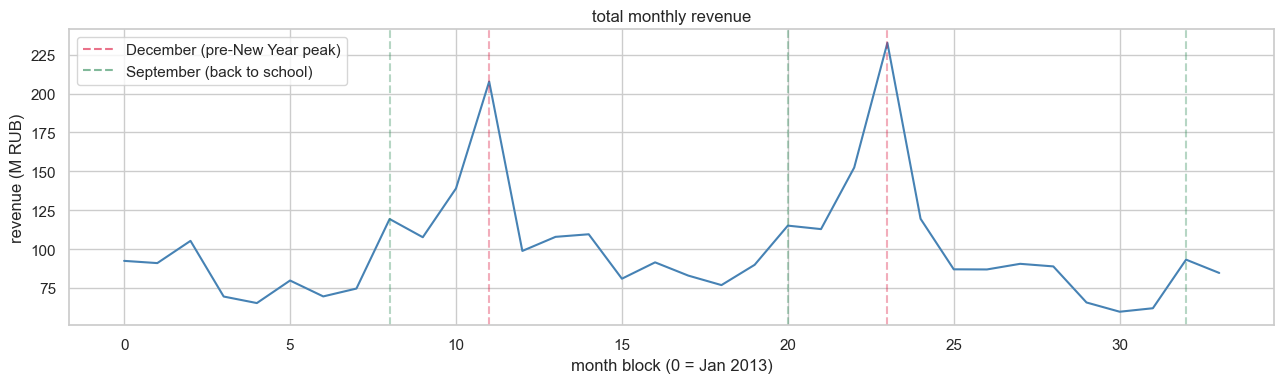

In [21]:
# 1a - total monthly revenue with new year and september markers
monthly_rev = sales.groupby('date_block_num')['revenue'].sum() / 1e6

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_rev.index, monthly_rev.to_numpy(), color='steelblue', linewidth=1.5)
for m in [11, 23]:
    ax.axvline(m, color='crimson', alpha=0.35, linestyle='--')
for m in [8, 20, 32]:
    ax.axvline(m, color='seagreen', alpha=0.35, linestyle='--')
handles = [
    Line2D([0], [0], color='crimson', linestyle='--', alpha=0.6, label='December (pre-New Year peak)'),
    Line2D([0], [0], color='seagreen', linestyle='--', alpha=0.6, label='September (back to school)'),
]
ax.legend(handles=handles)
ax.set_title('total monthly revenue')
ax.set_ylabel('revenue (M RUB)')
ax.set_xlabel('month block (0 = Jan 2013)')
plt.tight_layout()
plt.show()

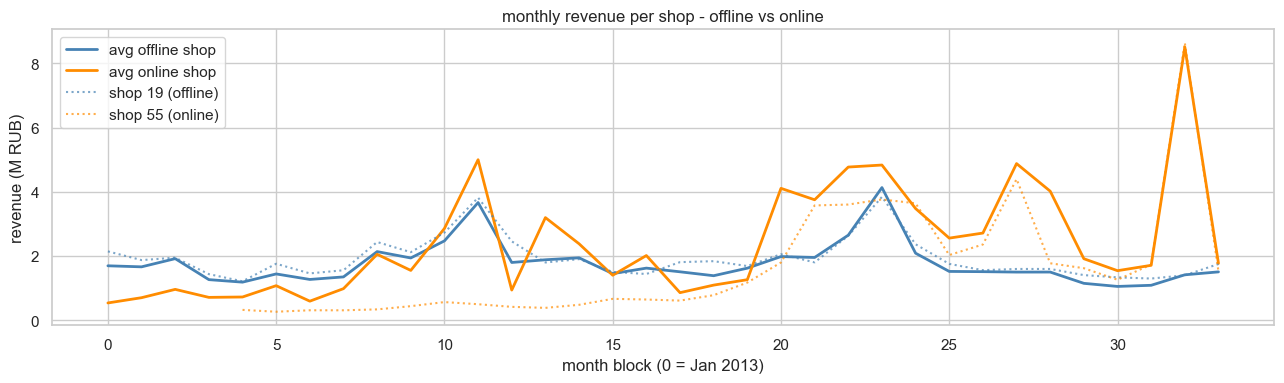

sample offline shop id: 19 | online shop id: 55


In [22]:
# 1b - avg monthly revenue per shop by channel + one sample shop from each
offline_ids = sales.loc[sales['channel'] == 'offline', 'shop_id'].unique()
online_ids = sales.loc[sales['channel'] == 'online', 'shop_id'].unique()

rng = np.random.default_rng(42)
s_off = int(rng.choice(offline_ids))
s_on = int(rng.choice(online_ids))

avg_off = sales[sales['channel'] == 'offline'].groupby('date_block_num')['revenue'].sum() / len(offline_ids) / 1e6
avg_on = sales[sales['channel'] == 'online'].groupby('date_block_num')['revenue'].sum() / len(online_ids) / 1e6
line_off = sales[sales['shop_id'] == s_off].groupby('date_block_num')['revenue'].sum() / 1e6
line_on = sales[sales['shop_id'] == s_on].groupby('date_block_num')['revenue'].sum() / 1e6

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(avg_off.index, avg_off.to_numpy(), label='avg offline shop', color='steelblue', linewidth=2)
ax.plot(avg_on.index, avg_on.to_numpy(), label='avg online shop', color='darkorange', linewidth=2)
ax.plot(line_off.index, line_off.to_numpy(), label=f'shop {s_off} (offline)', color='steelblue', linestyle=':', alpha=0.7)
ax.plot(line_on.index, line_on.to_numpy(), label=f'shop {s_on} (online)', color='darkorange', linestyle=':', alpha=0.7)
ax.set_title('monthly revenue per shop - offline vs online')
ax.set_ylabel('revenue (M RUB)')
ax.set_xlabel('month block (0 = Jan 2013)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'sample offline shop id: {s_off} | online shop id: {s_on}')

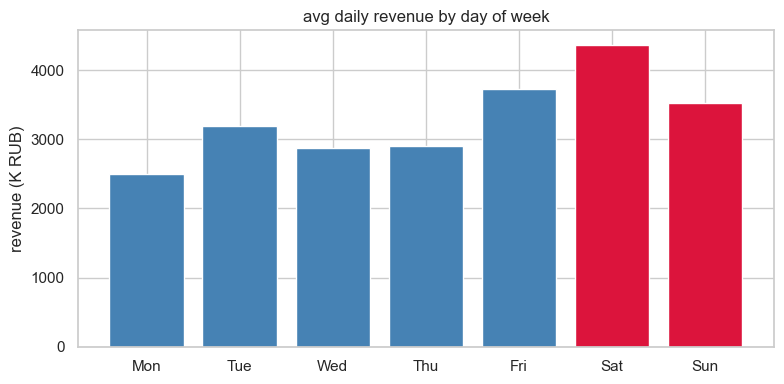

In [23]:
# 1c - day-of-week pattern, weekends highlighted
daily_rev = sales.groupby(['date', 'dow'])['revenue'].sum().reset_index()
dow_avg = daily_rev.groupby('dow')['revenue'].mean() / 1e3
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['crimson' if i >= 5 else 'steelblue' for i in range(7)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(7), dow_avg.reindex(range(7)).to_numpy(), color=colors)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_title('avg daily revenue by day of week')
ax.set_ylabel('revenue (K RUB)')
plt.tight_layout()
plt.show()

## 4.2 ABC / XYZ Segmentation

In [24]:
# 2 - ABC classification (pareto) + XYZ (demand stability)

# ABC: rank items by revenue, find how many cover 80% / 95%
item_rev = sales.groupby('item_id')['revenue'].sum().sort_values(ascending=False)
cum_pct = item_rev.cumsum() / item_rev.sum() * 100

n_A = int((cum_pct <= 80).sum())
n_B = int(((cum_pct > 80) & (cum_pct <= 95)).sum())
n_C = int((cum_pct > 95).sum())
total_items = len(item_rev)

print('ABC classification:')
print(f'A (top 80% revenue):  {n_A:,} items ({n_A/total_items*100:.1f}%)')
print(f'B (80-95%):           {n_B:,} items ({n_B/total_items*100:.1f}%)')
print(f'C (others):           {n_C:,} items ({n_C/total_items*100:.1f}%)')

# XYZ: cv of monthly quantity (qty) - how stable the demand is
item_cv = monthly.groupby('item_id')['item_cnt_month'].agg(mean='mean', std='std')
item_cv['cv'] = item_cv['std'] / item_cv['mean'].replace(0, np.nan)

def xyz_class(cv):
    if pd.isna(cv) or cv >= 1.0:
        return 'Z'
    if cv >= 0.5:
        return 'Y'
    return 'X'

item_cv['xyz'] = item_cv['cv'].map(xyz_class)
n_X = int((item_cv['xyz'] == 'X').sum())
n_Y = int((item_cv['xyz'] == 'Y').sum())
n_Z = int((item_cv['xyz'] == 'Z').sum())

print('\nXYZ classification (demand stability):')
print(f'Y (variable):    {n_Y:,} items' )
print(f'X (stable):      {n_X:,} items')
print(f'Z (chaotic):     {n_Z:,} items')

# golden items: A + X (building a union set of items which are both in A and X).
#bins here are essentially borders which detemina 
# which product goes to which set (A,B or C)
#we use -0.01 instead of 0 bc otherwise the product with 
# cumulative % ~=0 wouldnt be distributed to any class 
abc_lookup = dict(zip(cum_pct.index, pd.cut(cum_pct.values, bins=[-0.01, 80, 95, 100], labels=['A', 'B', 'C'])))
item_cv['abc'] = item_cv.index.map(abc_lookup)
golden = int(((item_cv['abc'] == 'A') & (item_cv['xyz'] == 'X')).sum())
print(f'\ngolden items (high revenue and stable demand): {golden:,}')

ABC classification:
A (top 80% revenue):  1,671 items (7.7%)
B (80-95%):           4,260 items (19.5%)
C (others):           15,872 items (72.8%)

XYZ classification (demand stability):
Y (variable):    5,227 items
X (stable):      12,195 items
Z (chaotic):     4,381 items

golden items (high revenue and stable demand): 106


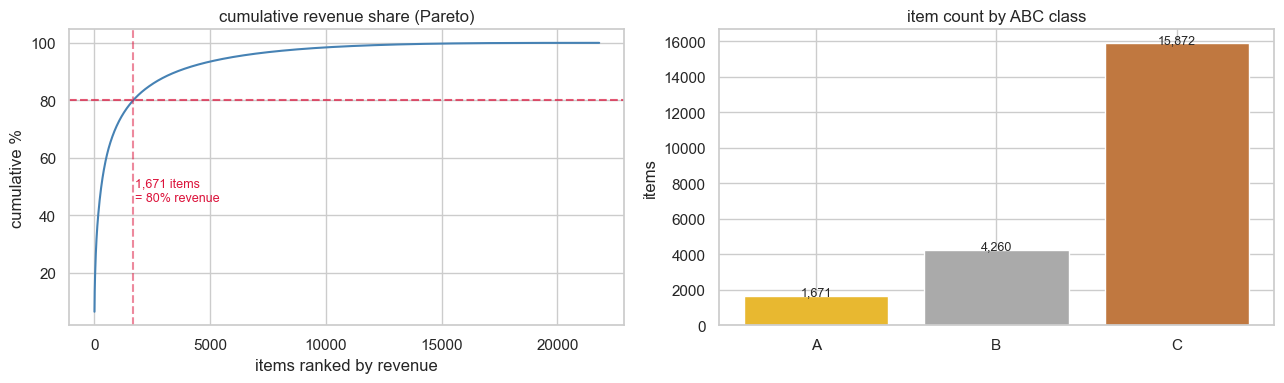

In [25]:
# plot pareto curve and item count per class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(len(cum_pct)), cum_pct.to_numpy(), color='steelblue', linewidth=1.5)
ax.axhline(80, color='crimson', linestyle='--', alpha=0.7)
ax.axvline(n_A, color='crimson', linestyle='--', alpha=0.5)
ax.text(n_A + 100, 45, f'{n_A:,} items\n= 80% revenue', fontsize=9, color='crimson')
ax.set_title('cumulative revenue share (Pareto)')
ax.set_xlabel('items ranked by revenue')
ax.set_ylabel('cumulative %')

ax = axes[1]
ax.bar(['A', 'B', 'C'], [n_A, n_B, n_C], color=['#e8b830', '#aaaaaa', '#c07840'])
for i, v in enumerate([n_A, n_B, n_C]):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
ax.set_title('item count by ABC class')
ax.set_ylabel('items')

plt.tight_layout()
plt.show()

In [26]:
# top 20 class A items and top 20 golden items table is loaded in the 
# load cell at the top
rev_df = item_rev.reset_index().rename(columns={'revenue': 'total_rev'})
rev_df['cum_pct'] = cum_pct.values #cumulative profit percent
rev_df['abc'] = rev_df['item_id'].map(abc_lookup)
rev_df = rev_df.merge(item_cv[['xyz', 'cv']], left_on='item_id', right_index=True, how='left')
rev_df = rev_df.merge(items[['item_id', 'item_name']], on='item_id', how='left')

def show(df, cols):
    out = df[cols].copy().reset_index(drop=True)
    out.index += 1
    out['item_name'] = out['item_name'].str[:55]
    out['total_rev'] = out['total_rev'].apply(lambda x: f'{x/1e6:.1f}M RUB')
    out['cum_pct'] = out['cum_pct'].apply(lambda x: f'{x:.1f}%')
    if 'cv' in out.columns:
        out['cv'] = out['cv'].apply(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    return out

print('top 20 class-A items')
display(show(rev_df[rev_df['abc'] == 'A'].head(20), ['item_name', 'total_rev', 'cum_pct']))

print('\ntop 20 golden items (high revenue, stable demand)')
golden_top = rev_df[(rev_df['abc'] == 'A') & (rev_df['xyz'] == 'X')].head(20)
display(show(golden_top, ['item_name', 'total_rev', 'cum_pct', 'cv']))

top 20 class-A items


,item_name,total_rev,cum_pct
1,Sony PlayStation 4 (500 Gb) Black (CUH-1008A/1...,220.0M RUB,6.5%
2,"Grand Theft Auto V [PS3, русские субтитры]",43.7M RUB,7.7%
3,Комплект Sony PS4 (500 Gb) Black (CUH-1108A/B0...,34.4M RUB,8.7%
4,"Grand Theft Auto V [Xbox 360, русские субтитры]",31.2M RUB,9.7%
5,"Grand Theft Auto V [PS4, русские субтитры]",22.4M RUB,10.3%
6,"Одни из нас [PS3, русская версия]",22.0M RUB,11.0%
7,"Grand Theft Auto V [PC, русские субтитры]",20.0M RUB,11.5%
8,"Комплект ""Microsoft Xbox One 500GB (Day One Ed...",18.2M RUB,12.1%
9,Прием денежных средств для 1С-Онлайн,17.2M RUB,12.6%
10,Playstation Store пополнение бумажника: Карта ...,17.2M RUB,13.1%



top 20 golden items (high revenue, stable demand)


,item_name,total_rev,cum_pct,cv
1,Комплект Sony PS Vita 3G/WiFi Black Rus (PCH-1...,3.3M RUB,38.7%,0.47
2,Sony PlayStation 4 (500 Gb) Юбилейное издание ...,1.8M RUB,53.4%,0.26
3,Карта оплаты Xbox: 2000 рублей [Цифровая версия],1.5M RUB,56.6%,0.35
4,"1С:Деньги 8 Электронная версия [PC, Цифровая в...",1.3M RUB,59.8%,0.27
5,Sony PlayStation 3 Super Slim (12 Gb) Black Ru...,1.2M RUB,60.4%,0.44
6,"Комплект ""Microsoft Xbox 360 E 250GB"" + ""Forza...",1.2M RUB,60.9%,0.39
7,Карта оплаты Xbox: 1000 рублей [Цифровая версия],1.1M RUB,62.1%,0.30
8,Xbox 360 250 ГБ Darksiders 2 + Batman ArkhamCity,1.1M RUB,62.2%,0.49
9,3D GARDEN (Наш Сад 10) (box),1.0M RUB,63.2%,0.35
10,Динозавр Pleo rb Promo Pack,1.0M RUB,63.3%,0.30


## 4.3 Geography & Channels

avg transaction value:
  offline: 1,135 RUB
  online: 2,357 RUB


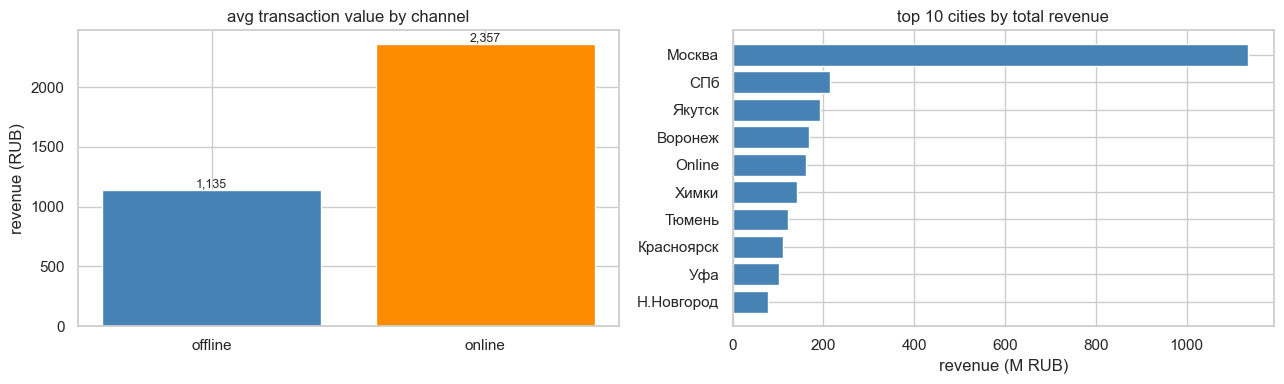

In [27]:
# 3a - avg transaction value by channel + top cities by revenue
ticket = sales.groupby('channel')['revenue'].mean()
print('avg transaction value:')
for ch, v in ticket.items():
    print(f'  {ch}: {v:,.0f} RUB')

city_rev = sales.groupby('city')['revenue'].sum().sort_values(ascending=False).head(10) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(ticket.index, ticket.to_numpy(), color=['steelblue', 'darkorange'])
for i, (ch, v) in enumerate(ticket.items()):
    ax.text(i, v + 30, f'{v:,.0f}', ha='center', fontsize=9)
ax.set_title('avg transaction value by channel')
ax.set_ylabel('revenue (RUB)')

ax = axes[1]
ax.barh(city_rev.index[::-1].to_numpy(), city_rev.to_numpy()[::-1], color='steelblue')
ax.set_title('top 10 cities by total revenue')
ax.set_xlabel('revenue (M RUB)')

plt.tight_layout()
plt.show()

correlation between monthly online and offline revenue: 0.451
positive - they move together, no clear problem signal


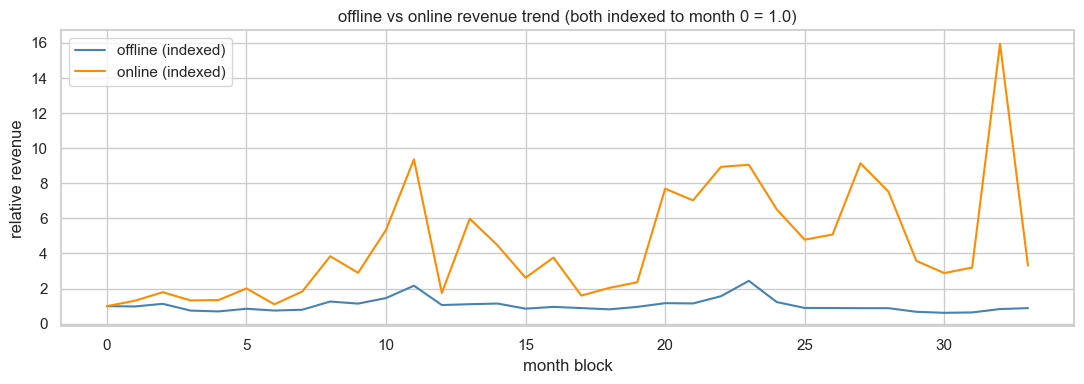

In [28]:
# 3b - "beef" check: does online growth correlate with offline decline?
ch_monthly = sales.groupby(['date_block_num', 'channel'])['revenue'].sum().unstack(fill_value=0) / 1e6
corr = float(ch_monthly['offline'].corr(ch_monthly['online']))
print(f'correlation between monthly online and offline revenue: {corr:.3f}')
if corr > 0:
    print('positive - they move together, no clear problem signal')
else:
    print('negative - could mean online is eating into offline')

# normalize both to month 0 so they fit on one axis
base_off = ch_monthly['offline'][ch_monthly['offline'] > 0].iloc[0]
base_on = ch_monthly['online'][ch_monthly['online'] > 0].iloc[0]
norm_off = ch_monthly['offline'] / base_off
norm_on = ch_monthly['online'] / base_on

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ch_monthly.index, norm_off.to_numpy(), color='steelblue', label='offline (indexed)', linewidth=1.5)
ax.plot(ch_monthly.index, norm_on.to_numpy(), color='darkorange', label='online (indexed)', linewidth=1.5)
ax.set_title('offline vs online revenue trend (both indexed to month 0 = 1.0)')
ax.set_ylabel('relative revenue')
ax.set_xlabel('month block')
ax.legend()
plt.tight_layout()
plt.show()

## 4.4 Lag Features Analysis

overall autocorrelation by lag:
 lag  corr   pairs
   1   0.5 1585569
   2   0.5 1566286
   3   0.5 1548138
   6   0.5 1497613
  12   0.4 1408142


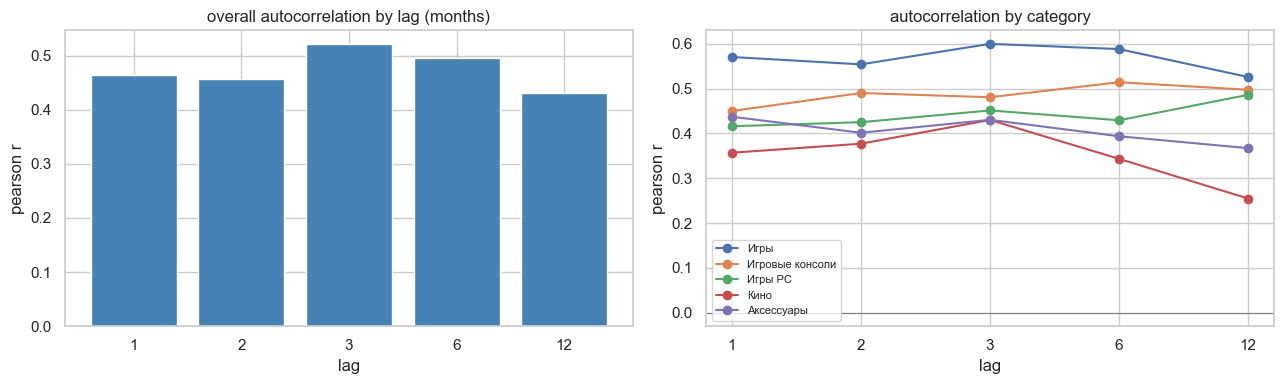

In [29]:
# how well does last month predict this month? compute autocorrelation for lags 1-12
monthly_s = monthly.sort_values(['item_id', 'date_block_num'])

lags = [1, 2, 3, 6, 12]
rows = []
for lag in lags:
    shifted = monthly_s.groupby('item_id')['item_cnt_month'].shift(lag)
    mask = shifted.notna()
    corr = float(monthly_s.loc[mask, 'item_cnt_month'].corr(shifted[mask]))
    rows.append({'lag': lag, 'corr': corr, 'pairs': int(mask.sum())})

lag_df = pd.DataFrame(rows)
print('overall autocorrelation by lag:')
print(lag_df.to_string(index=False))

# same but broken down by top 5 categories
top_cats = (
    monthly.groupby('category_group')['revenue_month']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
top_cats = [c for c in top_cats if c not in ('Подарки', 'Служебные')][:5]

cat_corrs = {}
for cat in top_cats:
    cat_data = monthly_s[monthly_s['category_group'] == cat]
    corrs = []
    for lag in lags:
        shifted = cat_data.groupby('item_id')['item_cnt_month'].shift(lag)
        mask = shifted.notna()
        corr = float(cat_data.loc[mask, 'item_cnt_month'].corr(shifted[mask]))
        corrs.append(corr)
    cat_corrs[cat] = corrs

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar([str(l) for l in lags], lag_df['corr'].to_numpy(), color='steelblue')
ax.set_title('overall autocorrelation by lag (months)')
ax.set_xlabel('lag')
ax.set_ylabel('pearson r')
ax.axhline(0, color='gray', linewidth=0.8)

ax = axes[1]
for cat, corrs in cat_corrs.items():
    ax.plot([str(l) for l in lags], corrs, marker='o', label=cat, linewidth=1.5)
ax.set_title('autocorrelation by category')
ax.set_xlabel('lag')
ax.set_ylabel('pearson r')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The strongest signal is lag_1 - what sold last month is the best predictor of what will sell this month. lag_2 adds something on top of that, and lag_12 picks up the yearly seasonal pattern. On the time side, month and quarter are the most useful. From the dimension tables, category_group, city and channel all carry meaningful signal since demand shapes differ a lot across these groups.

One caveat: for about a quarter of the catalog the lag features are going to be missing or noisy because those items only have 3 months of history or less. For those, category-level averages are the fallback.

## 4.5 Entity Interactions

How do categories and shops relate to each other, and how does seasonality differ across product types?
- **Category x Month** - which categories peak at which month , which are stable during the year
- **City x Category** - do different cities specialize in different product types ? 

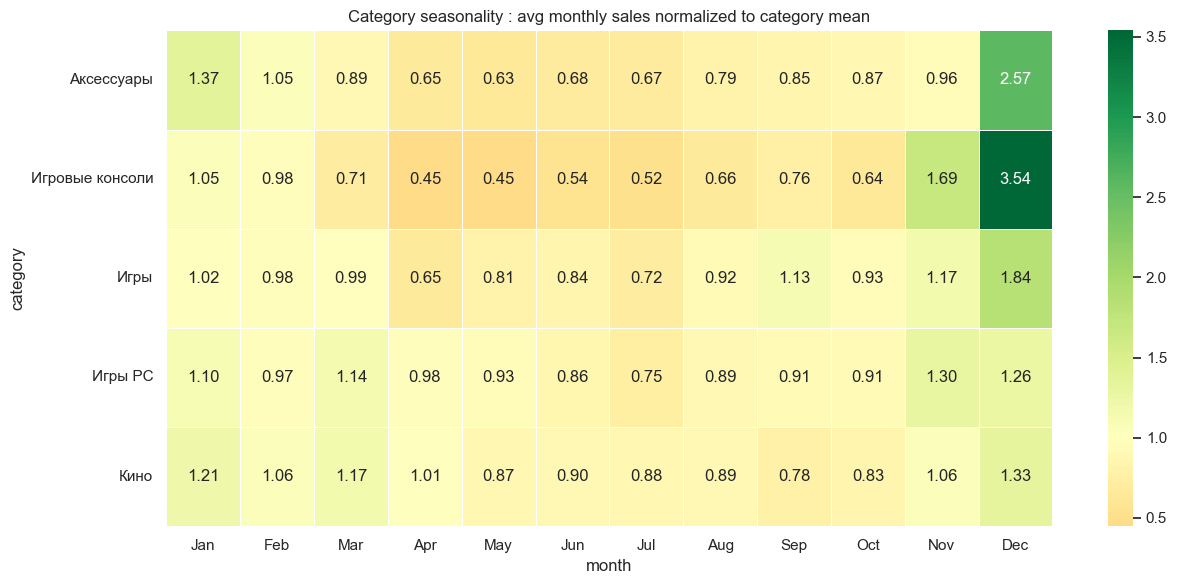

In [30]:
import calendar

# top 10 categories by volume, exclude service/gift/event categories
top_categories = (
    monthly.groupby('category_group')['item_cnt_month']
    .sum()
    .sort_values(ascending=False)
    .drop(['Служебные', 'Подарки', 'Билеты (Цифра)'], errors='ignore')
    .head(10)
    .index.tolist()
)

# aggregate to category/block totals first, then average by month of the year
categories_totals = (
    monthly[monthly['category_group'].isin(top_cats)]
    .groupby(['date_block_num', 'category_group'])['item_cnt_month']
    .sum()
    .reset_index()
)
categories_totals['month'] = (categories_totals['date_block_num'] % 12) + 1

categories_season = (
    categories_totals.groupby(['category_group', 'month'])['item_cnt_month']
    .mean()
    .unstack(fill_value=0)
)
category_season_norm = categories_season.div(categories_season.mean(axis=1), axis=0)
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    category_season_norm,
    ax=ax,
    cmap='RdYlGn',
    center=1.0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    xticklabels=month_labels,
)
ax.set_title('Category seasonality : avg monthly sales normalized to category mean') #1.0 = avg
ax.set_xlabel('month')
ax.set_ylabel('category')
plt.tight_layout()
plt.show()

top 5 categories by revenue: ['Игры', 'Игровые консоли', 'Игры PC', 'Кино', 'Аксессуары']


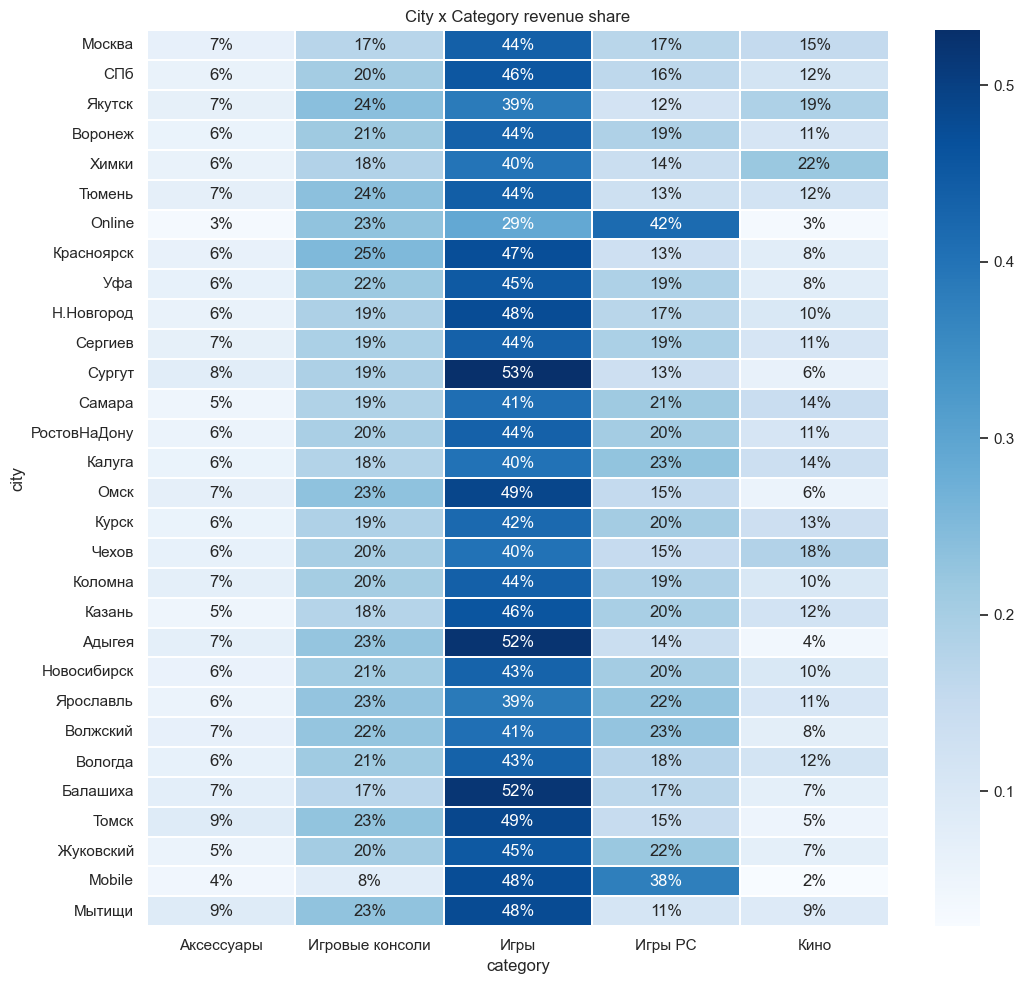

In [31]:
# city x category revenue share - which cities lean toward which product types
# use top 5 by revenue so only financially meaningful categories appear
exclude = {'Служебные', 'Подарки', 'Доставка товара', 'Билеты (Цифра)', 'Элементы питания'}
top_cats_rev = (
    monthly.groupby('category_group')['revenue_month']
    .sum()
    .sort_values(ascending=False)
    .drop(list(exclude), errors='ignore')
    .head(5)
    .index.tolist()
)
print('top 5 categories by revenue:', top_cats_rev)

city_cat = (
    monthly[monthly['category_group'].isin(top_cats_rev)]
    .groupby(['city', 'category_group'])['revenue_month']
    .sum()
    .unstack(fill_value=0)
)
city_cat_share = city_cat.div(city_cat.sum(axis=1), axis=0) #adds up to 100%
city_order = city_cat.sum(axis=1).sort_values(ascending=False).index
city_cat_share = city_cat_share.loc[city_order]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    city_cat_share,
    ax=ax,
    cmap='Blues',
    annot=True,
    fmt='.0%',
    linewidths=0.3,
)
ax.set_title('City x Category revenue share')
ax.set_xlabel('category')
ax.set_ylabel('city') # sorted by total revenue
plt.tight_layout()
plt.show()

## EDA Summary

Here's what we found:

**Time series:**

Kicking off with some global time-related trends and online-offline categories battle. Investigating anomalies, special dates, and so on. We also added avg monthly revenue of 2 random shops, each from one category. Just for fun.

- December is the clear revenue peak every year, with a secondary bump in September
- Saturday is the busiest day of the week; weekdays are noticeably quieter
- online channel has a steadier, flatter curve - offline is much more seasonal and spiky

**ABC / XYZ:**

At this step we investigate our top sellers: firstly the number of products which are responsible for 80% of profit (class A) and so-called golden items (class A+X). Then top 20 sellers in each of these classes, their share in total sales and the sales absolute values.

- only a small fraction of all items fall into class A - the rest is a long revenue tail
- the majority of items land in Z class meaning most of the catalog is hard to forecast reliably
- golden items are rare, but they're the safest bet for building an accurate prediction model

**Geography & Channels:**

Here we trying to figure out the patterns in sales by looking at the top cities by spendings and checking how purchases in online correlate with the offline ones. We calculate the total online sales and setting them to act like one city on the dedicated histogram for transparency.

- avg online transaction is significantly higher than offline, driven by software and digital goods
- no cannibalization signal - both channels trend together rather than competing
- Moscow (obviously) dominates by a large margin, followed by "Online" as a single "city"

**Lag Features:**

In this section we discover the correlation, e.g how well past sales predict future sales of each category to check if this dataset is suitable for a potential machine learning model. This is mainly obviously also needed to even better understand seasonality over some period of time.

- lag-1 (previous month) is the strongest predictor of current month sales
- autocorrelation drops with distance, but lag-12 picks up yearly seasonality
- categories differ: some have strong month-to-month persistence, others are more irregular
- lag-1, lag-2 and lag-12 are the most valuable features to include in the model

**Entity Interactions:**

Here we look at how categories and cities relate to each other - which product types have distinct seasonal patterns, and whether different cities specialize in different categories.

- games and consoles have the sharpest December spike; music and movies are flatter year-round
- the September bump is most visible in accessories and software categories
- Moscow and Online show the most diverse category mix; smaller cities lean heavily on 1-2 categories
- category seasonality patterns directly inform which seasonal multiplier to apply per product type when building a manual prediction rule

# 5. Prediction and Known Problems

## How to predict manually

The simplest honest approach is to use lag 1 as the base and adjust for seasonality. For items with a decent history you take last month's sales and multiply by the category coefficient for the target month - December for games is roughly 1.5x the average month, January is well below. For items with only a few months of data lag 1 is too noisy, so you fall back to the category mean. For the 363 items that never appeared in training you have nothing else to go on besides the category mean anyway.

The 106 golden items are a special case : stable demand and long history mean lag 1 alone is already a solid prediction with minimal adjustment needed.

## Known problems

The main headache is that for the most of the catalog is demand is chaotic and no method will predict it well. Cold start and short history make it worse for a specific batch of items. 

The test set only covers 42 of 60 shops, so some shop-item pairs the model never saw in training. 

We only have 3 years of data, so each November appears exactly 3 times in training - if one of those years was unusual for reasons unrelated to seasonality, that anomaly is third of the weight when estimating a normal November.
